# Week 6 Report

**Date:** 2026-06-29 to 2026-07-02

## Goals for this week

- [ ] Heterscedasticity in Residuals - Bin for box plots, plot station heteroscedasticity, determine significance
- [ ] Outline planned narrative/message of paper
- [ ] Draft Data section for paper

## What I did

To start this week, I placed my focus on the tasks related to heteroscedasticity. I first binned my data into a set number of bins and plotted box plots for it, before also plotting the residuals on a strip plot. Then, I defined a function that subsetted the residuals data by station and plotted box plots for each station, which I iterated over a list of the stations with the longest record of data complete data, omitting those whose data stopped before the 2020s. I also defined a similar function that plotted given subsets of my residuals, and iterated over a set of subsets dividing up the data by geographic location, proximity to a coastline, and elevation.

After the completion of this analysis, I worked to outline my planned paper narrative, focusing on potential takeaways I hoped to corraborate with data analysis, and potential hypotheses that could be use to further hone our guiding question. I also drafted a simple first draft of the data section of my paper. Both of these drafts can be found in markdown later in this report.

Then I fitted bayesian models for GSL, LSF, and FFF based on a chosen set of covariates including DTR, climate indices, and station moisture data. The predictions made by this model appear to indicate some connection between certain covariates and GSL, and the 95% credible interval for effect of year on variance does not contain 0, so the results are significant. 

Other points of interest from this weeks work include:
* Noticed a potential periodic cycle in the plotted residuals, might merit reconsideration of the potential cyclical pattern we identified in the temporal autocorrelation for the time interval from 1960-2025.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import statsmodels.api as sm
import seaborn as sns
pa_gs = pd.read_csv('/home/reu/project/data/pa_data.csv')

In [11]:
def remove_nulls_ext(data_subset, X, y, Z):
        # Drop rows where any of the specified X columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=X, ignore_index=True)
        # Separate the cleaned dataframe back into X and y
        X_cleaned = data_subset_cleaned[X]
        y_cleaned = data_subset_cleaned[y]
        Z_cleaned = data_subset_cleaned[Z]
        return X_cleaned, y_cleaned, Z_cleaned

# DEFINING VARIABLE LISTS

y = ['growing_season_length']
X = ['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'latitude', 'longitude', 'oni_annual',
    'nao_djf', 'pna_annual', 'amo_annual', 'sst_north_atlantic',
    'pwat_station', 'dewpoint_2m_pennsylvania', 'soil_moisture_station','cloud_cover_station', 'evaporation_station'] 
Z = ['year', 'station_name']

#DEFINING SUBSETS

coastal_pa_stations = pa_gs[pa_gs['dist_atlantic_km']< 150]
lakeside_pa_stations = pa_gs[pa_gs['dist_greatlakes_km']< 150]
inland_pa_stations = pa_gs[pa_gs['dist_coast_km']>150]
east_pa_stations = pa_gs[pa_gs['longitude'] < -77.569]
west_pa_stations = pa_gs[pa_gs['longitude'] > -77.569]
north_pa_stations = pa_gs[pa_gs['latitude'] > 40.58]
south_pa_stations = pa_gs[pa_gs['latitude'] < 40.58]
low_elevation_pa_stations = pa_gs[pa_gs['elevation_m'] > 371.9]
high_elevation_pa_stations = pa_gs[pa_gs['elevation_m'] <139.9]

subsets = {'Coastal': coastal_pa_stations, 'Lakeside': lakeside_pa_stations, 'Inland': inland_pa_stations,
           'Eastern': east_pa_stations, 'Western': west_pa_stations, 'Northern': north_pa_stations, 'Southern': south_pa_stations,
           'Low Elevation': low_elevation_pa_stations, 'High Elevation': high_elevation_pa_stations}

#DEFINING TOP STATIONS FOR PLOTTING

top_stations = ['STATE COLLEGE', 'WARREN', 'TOWANDA 1 S', 'FRANKLIN', 'UNIONTOWN 1 NE', 
                'NEW CASTLE 1 N', 'RIDGWAY', 'SELINSGROVE 2 S']

# LINEAR REGRESSION

X_all, y_all, Z_all = remove_nulls_ext(pa_gs, X, y, Z)
X_all= sm.add_constant(X_all)
             
mod_all = sm.OLS(y_all, X_all)
res_all = mod_all.fit()
#print(res_all.summary())

# RESIDUAL PLOTTING BY STATION

def station_residuals_plotting(station_name, bin_no):
    X_s, y_s, Z_s = remove_nulls_ext(pa_gs[pa_gs['station_name'] == station_name], X, y, Z)
    X_s= sm.add_constant(X_s)
                 
    mod_s = sm.OLS(y_s, X_s)
    res_s = mod_s.fit()
    #print(res_s.summary())
    
    residuals_s = res_s.resid
    res_df_s = residuals_s.to_frame()
    res_df_s = pd.concat([res_df_s, Z_s], axis=1)
    res_df_s.columns = ['residuals', 'year', 'station_name']
    
    res_df_s['bins'] = pd.cut(x= res_df_s['year'], bins = bin_no)
    res_df_s = res_df_s.sort_values(by='bins')
    
    
    fig, axs = plt.subplots(1,bin_no, sharey=True, figsize = (bin_no * 2, 5))
    fig.suptitle(f'Boxplots of Binned Multiple Regression Residuals Data for {station_name}, PA')
    fig.subplots_adjust(wspace = bin_no * 3/5)
    n = 0
    for value in res_df_s['bins'].unique():
        res_df_bin = res_df_s[res_df_s['bins'] == value]
        axs[n].boxplot(res_df_bin['residuals'], notch= True)
        axs[n].set_xlabel(f'{value}, {len(res_df_bin)} pts')
        n = n + 1
    plt.show()

    fig = plt.figure(figsize = (30,3))
    fig = sns.stripplot(data = res_df_s, x = 'year', y = 'residuals')
    plt.grid(axis='y')
    plt.title(f'Plotted Residuals for {station_name}')
    plt.show()

# RESIDUAL PLOTTING BY SUBSET

def subset_residuals_plotting(subset, subset_name, bin_no):
    X_s, y_s, Z_s = remove_nulls_ext(subset, X, y, Z)
    X_s= sm.add_constant(X_s)
                 
    mod_s = sm.OLS(y_s, X_s)
    res_s = mod_s.fit()
    #print(res_s.summary())
    
    residuals_s = res_s.resid
    res_df_s = residuals_s.to_frame()
    res_df_s = pd.concat([res_df_s, Z_s], axis=1)
    res_df_s.columns = ['residuals', 'year', 'station_name']
    
    res_df_s['bins'] = pd.cut(x= res_df_s['year'], bins = bin_no)
    res_df_s = res_df_s.sort_values(by='bins')
    
    
    fig, axs = plt.subplots(1,bin_no, sharey=True, figsize = (bin_no * 2, 5))
    fig.suptitle(f'Boxplots of Binned Multiple Regression Residuals Data for {subset_name} PA')
    fig.subplots_adjust(wspace = bin_no * 3/5)
    n = 0
    for value in res_df_s['bins'].unique():
        res_df_bin = res_df_s[res_df_s['bins'] == value]
        axs[n].boxplot(res_df_bin['residuals'], notch= True)
        axs[n].set_xlabel(f'{value}, {len(res_df_bin)} pts')
        n = n + 1
    plt.show()

    fig = plt.figure(figsize = (30, 3))
    fig = sns.stripplot(data = res_df_s, x = 'year', y = 'residuals')
    plt.grid(axis='y')
    plt.title(f'Plotted Residuals for {subset_name} PA')
    plt.show()

## Analysis

*(Add code and markdown cells as needed.)*

#### PA State Residuals, plotted against Time with box plots, strip plot, and line plot 

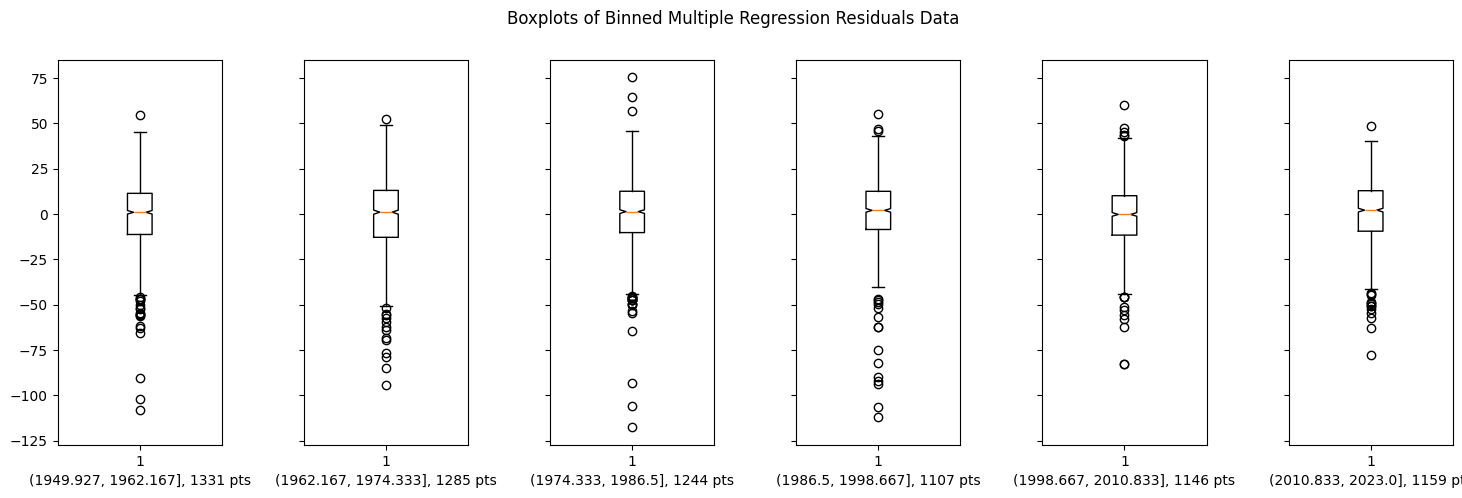

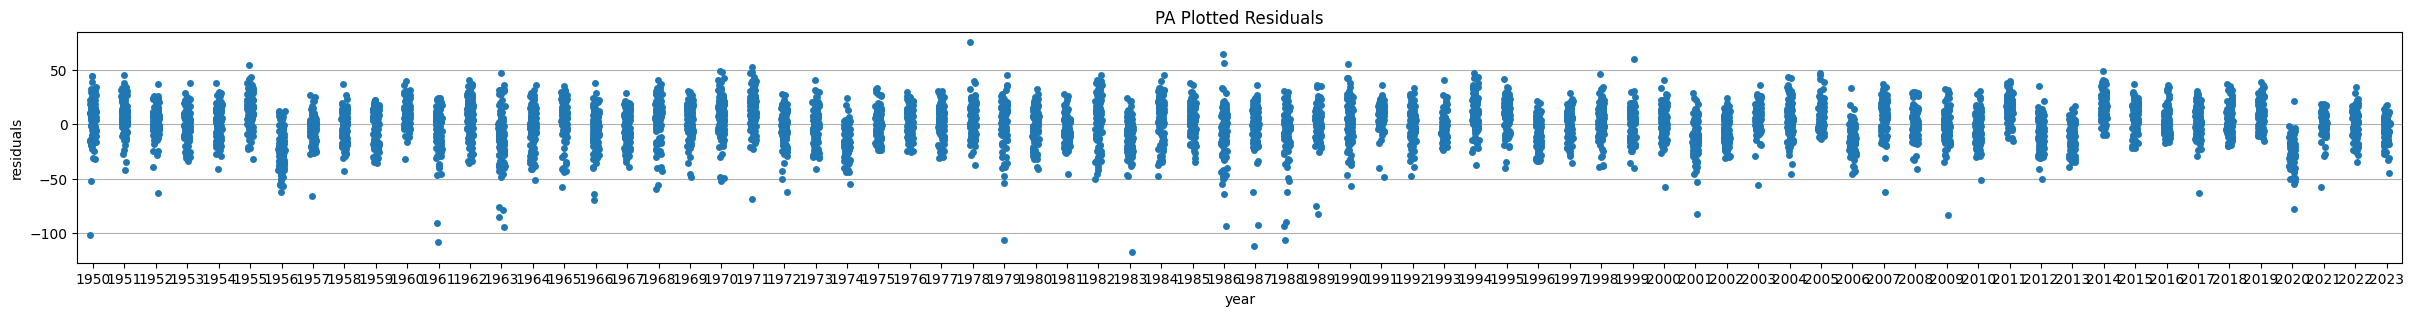

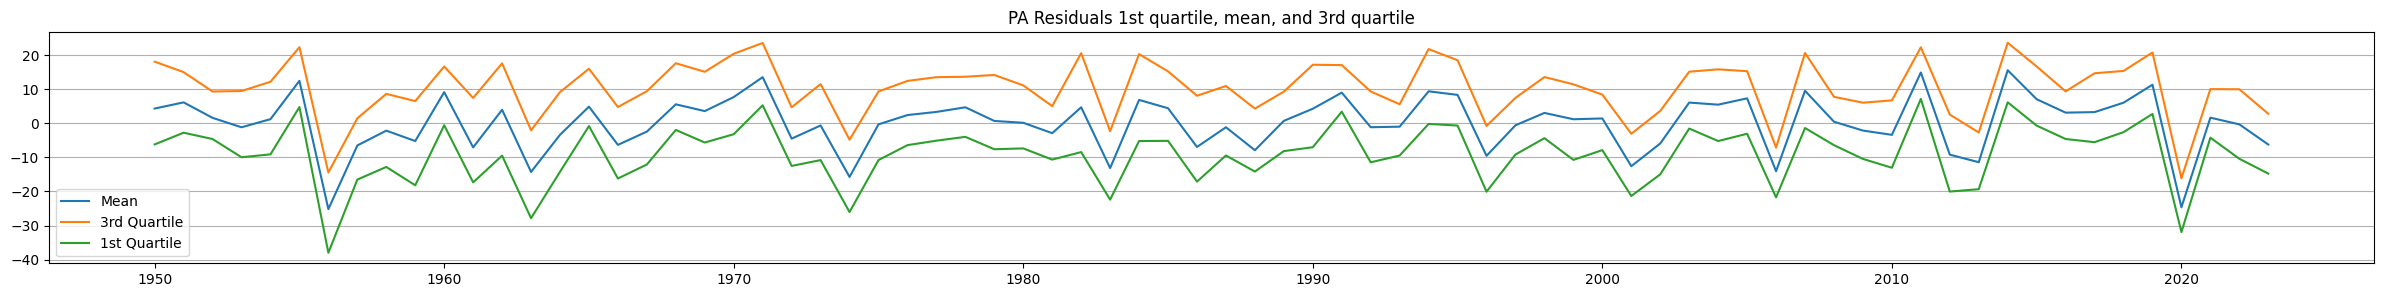

In [6]:
residuals_all = res_all.resid
res_df_all = residuals_all.to_frame()
res_df_all = pd.concat([res_df_all, Z_all], axis=1)
res_df_all.columns = ['residuals', 'year', 'station_name']

res_df_all['bins'] = pd.cut(x= res_df_all['year'], bins = 6)
res_df_all = res_df_all.sort_values(by='bins')


fig, axs = plt.subplots(1,6, sharey=True, figsize = (18, 5))
fig.suptitle('Boxplots of Binned Multiple Regression Residuals Data')
fig.subplots_adjust(wspace = 0.5)
n = 0
for value in res_df_all['bins'].unique():
    res_df_bin_all = res_df_all[res_df_all['bins'] == value]
    axs[n].boxplot(res_df_bin_all['residuals'], notch = True)
    axs[n].set_xlabel(f'{value}, {len(res_df_bin_all)} pts')
    n = n + 1
plt.show()

res_df_all_mean = res_df_all.groupby('year')['residuals'].mean()
res_df_all_mean = res_df_all_mean.to_frame()
res_df_all_mean = res_df_all_mean.reset_index()
res_df_all_mean.columns = ['year', 'residual_mean']

res_df_all_3q = res_df_all.groupby('year')['residuals'].quantile(0.75)
res_df_all_3q = res_df_all_3q.to_frame()
res_df_all_3q = res_df_all_3q.reset_index()
res_df_all_3q.columns = ['year', 'residual_3q']

res_df_all_1q = res_df_all.groupby('year')['residuals'].quantile(0.25)
res_df_all_1q = res_df_all_1q.to_frame()
res_df_all_1q = res_df_all_1q.reset_index()
res_df_all_1q.columns = ['year', 'residual_1q']

fig= plt.figure(figsize = (30,3))
fig = sns.stripplot(data = res_df_all, x = 'year', y = 'residuals')       
plt.grid(axis='y')
plt.title('PA Plotted Residuals')
plt.show

fig= plt.figure(figsize = (30,3))
fig = plt.plot(res_df_all_mean['year'], res_df_all_mean['residual_mean'], label = 'Mean')
fig = plt.plot(res_df_all_3q['year'], res_df_all_3q['residual_3q'], label = '3rd Quartile')
fig = plt.plot(res_df_all_1q['year'], res_df_all_1q['residual_1q'], label = '1st Quartile')
plt.grid(axis='y')
plt.title('PA Residuals 1st quartile, mean, and 3rd quartile')
plt.legend()
plt.show()

#### Residuals Plotted by Station

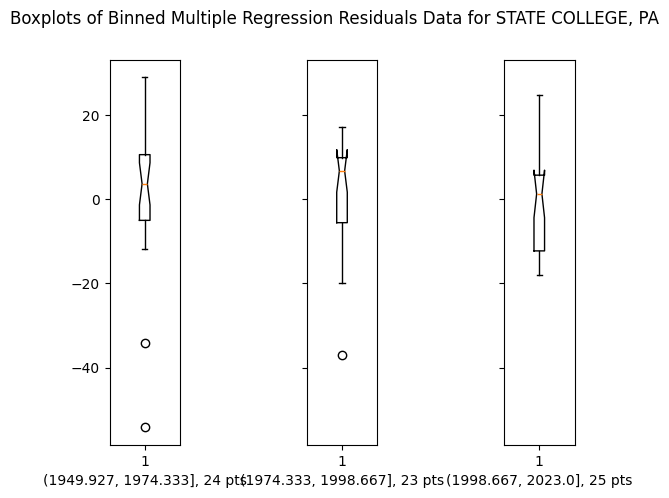

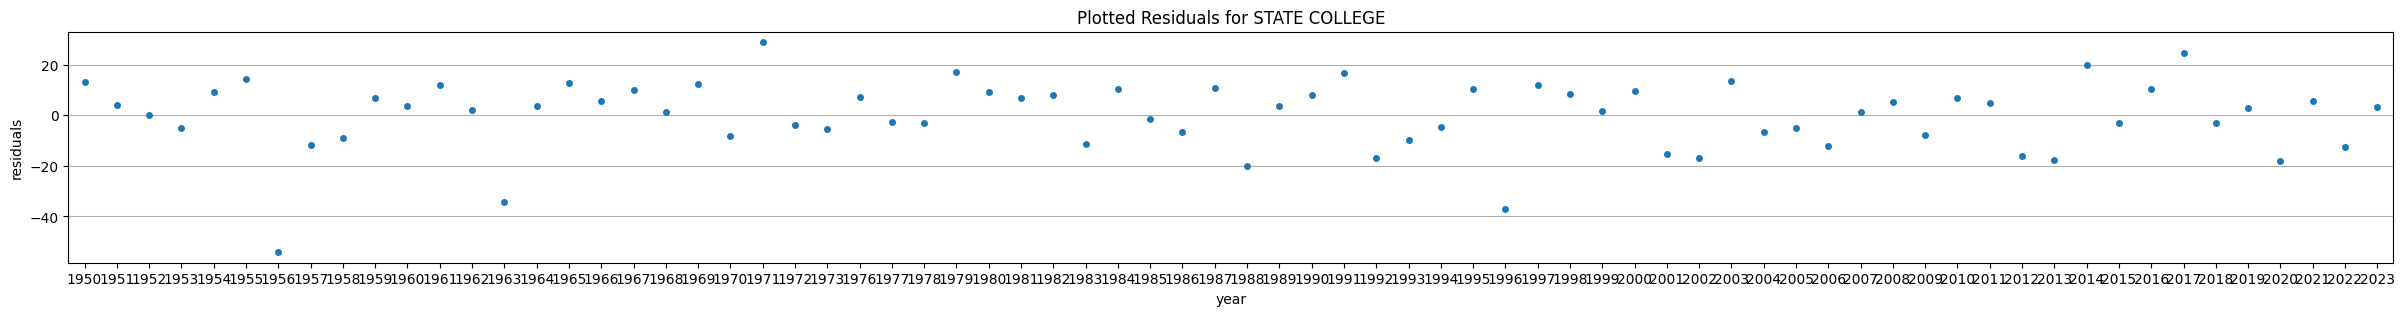

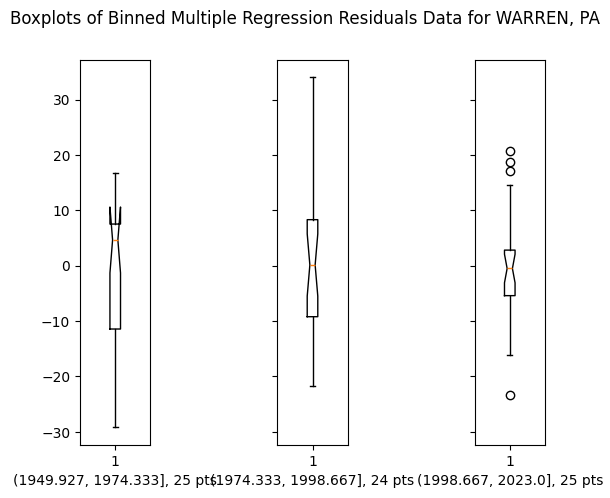

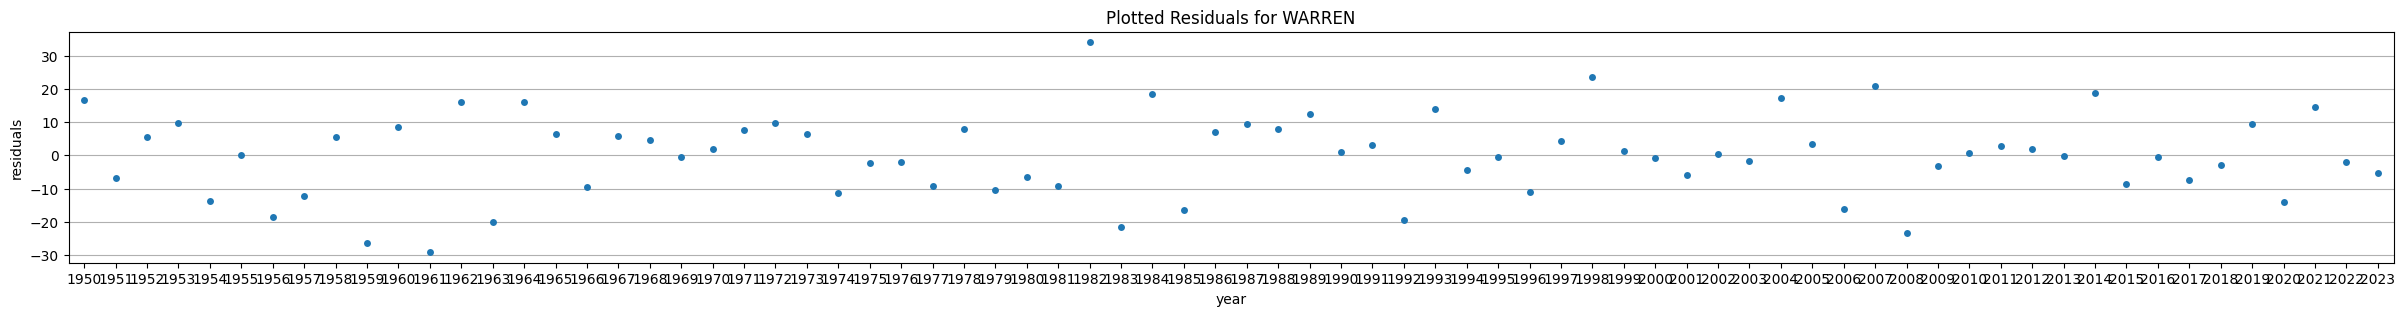

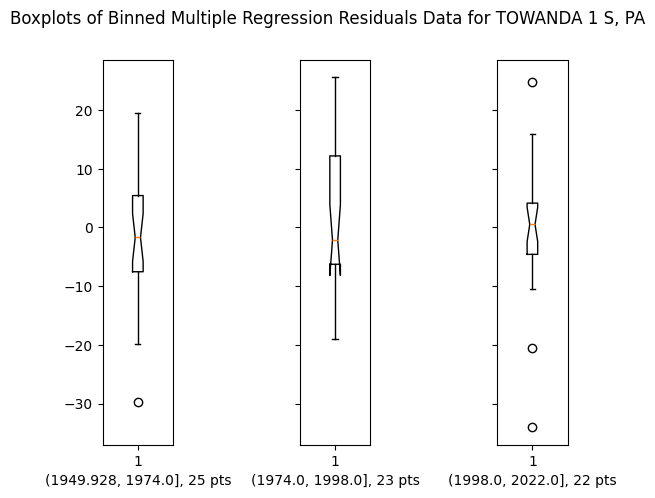

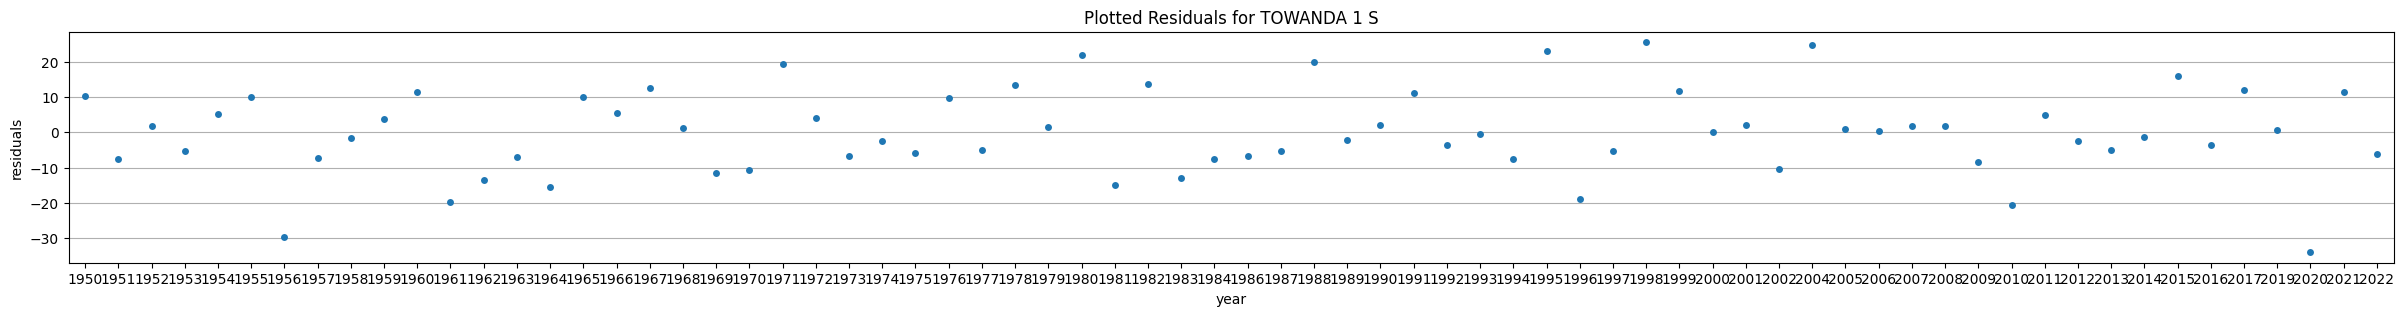

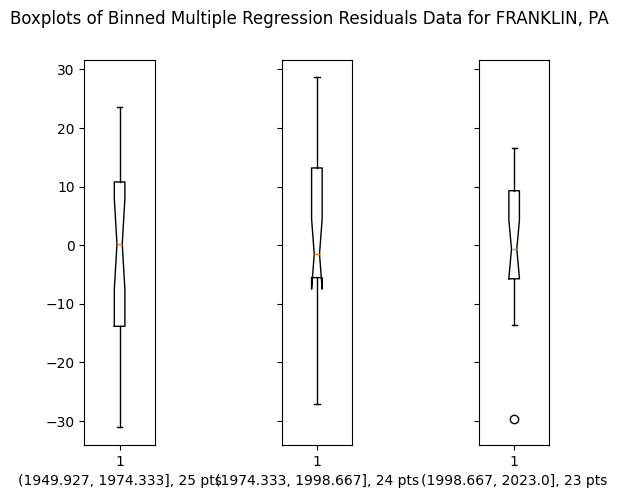

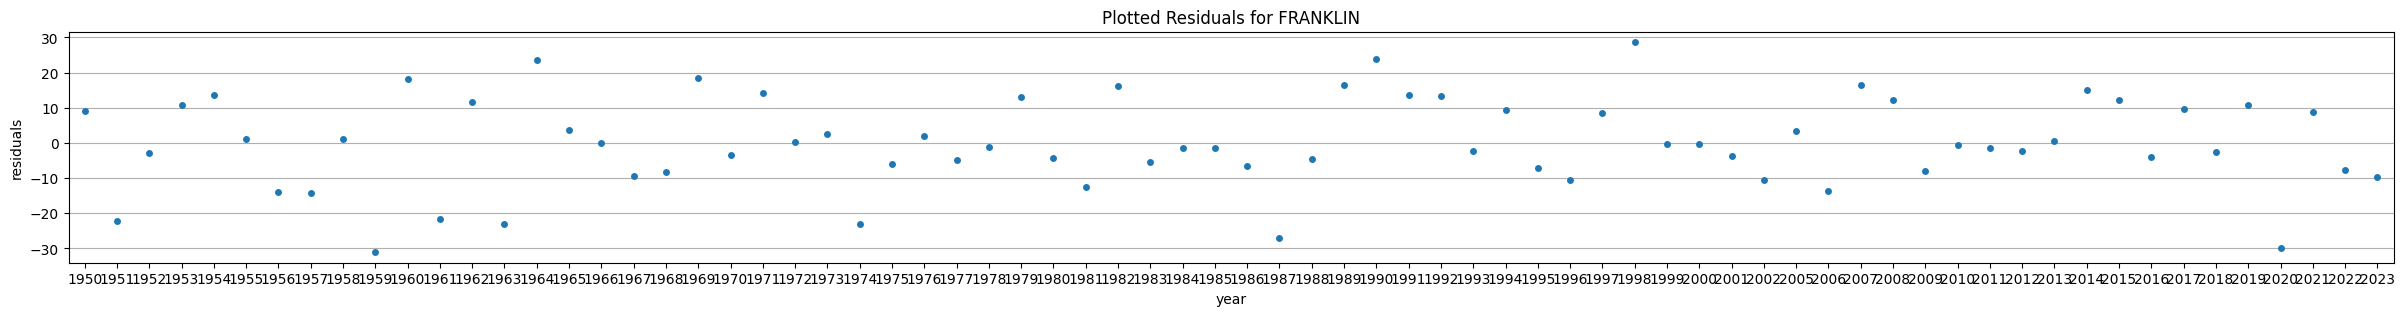

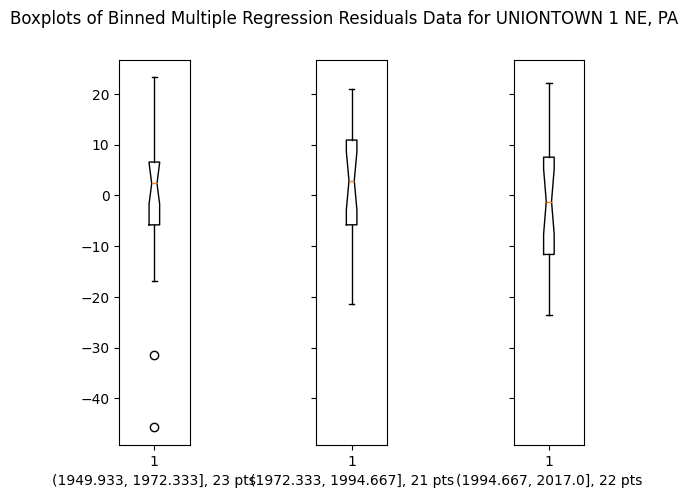

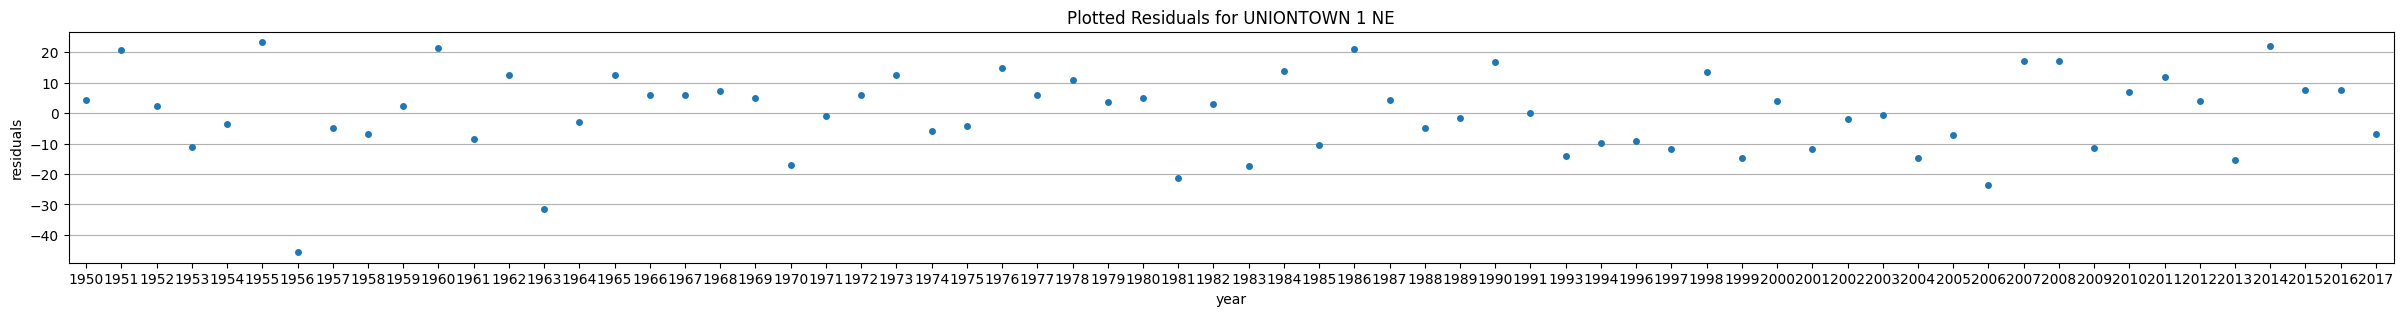

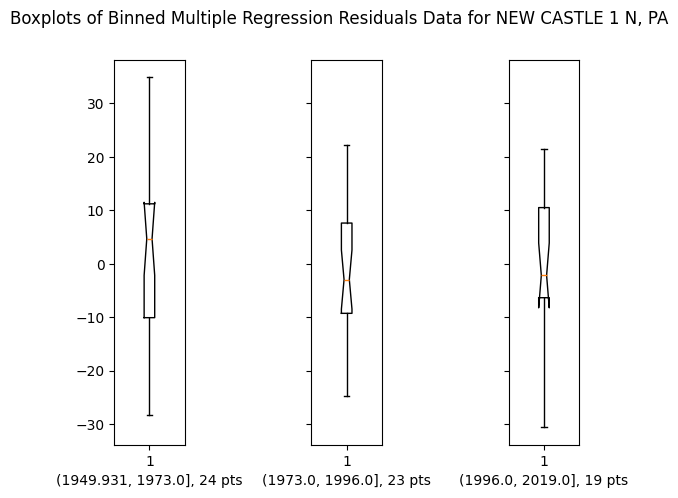

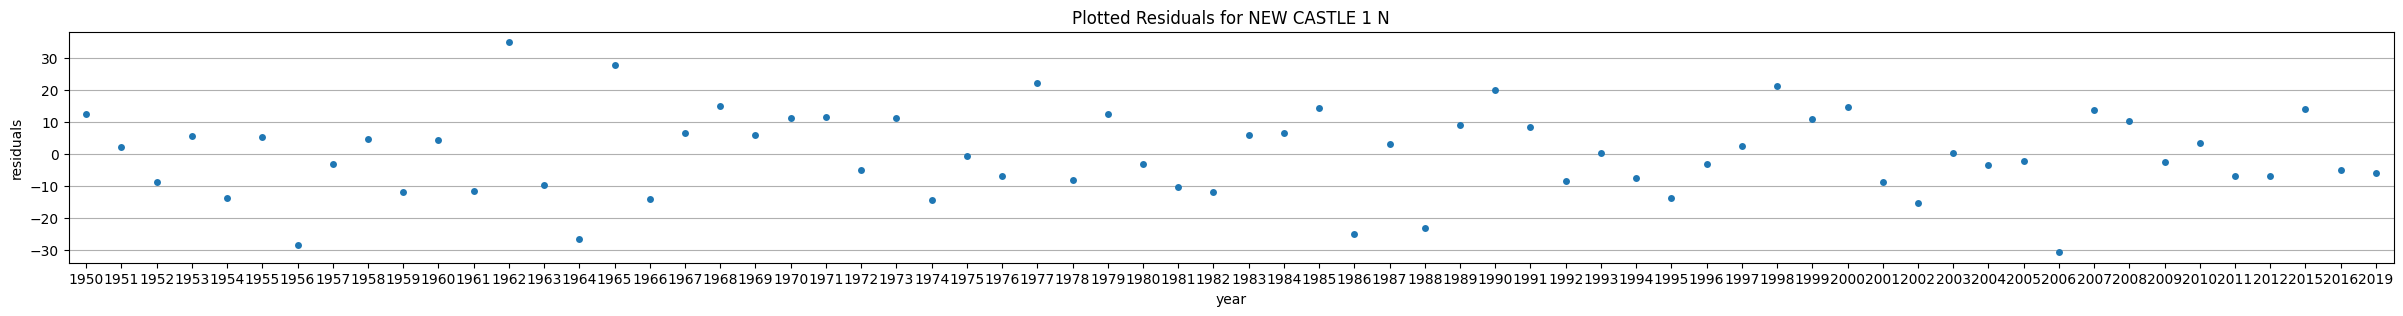

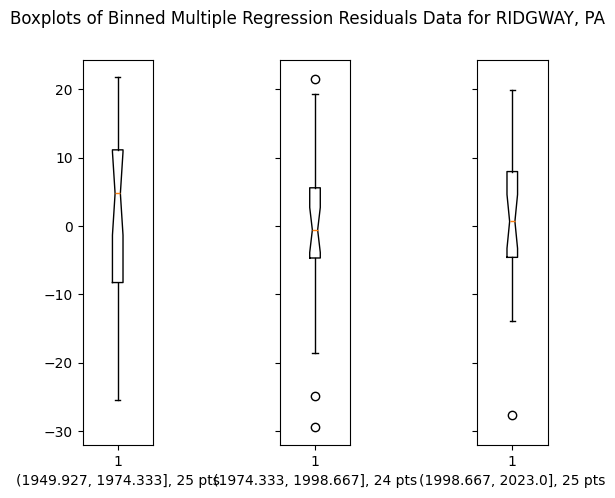

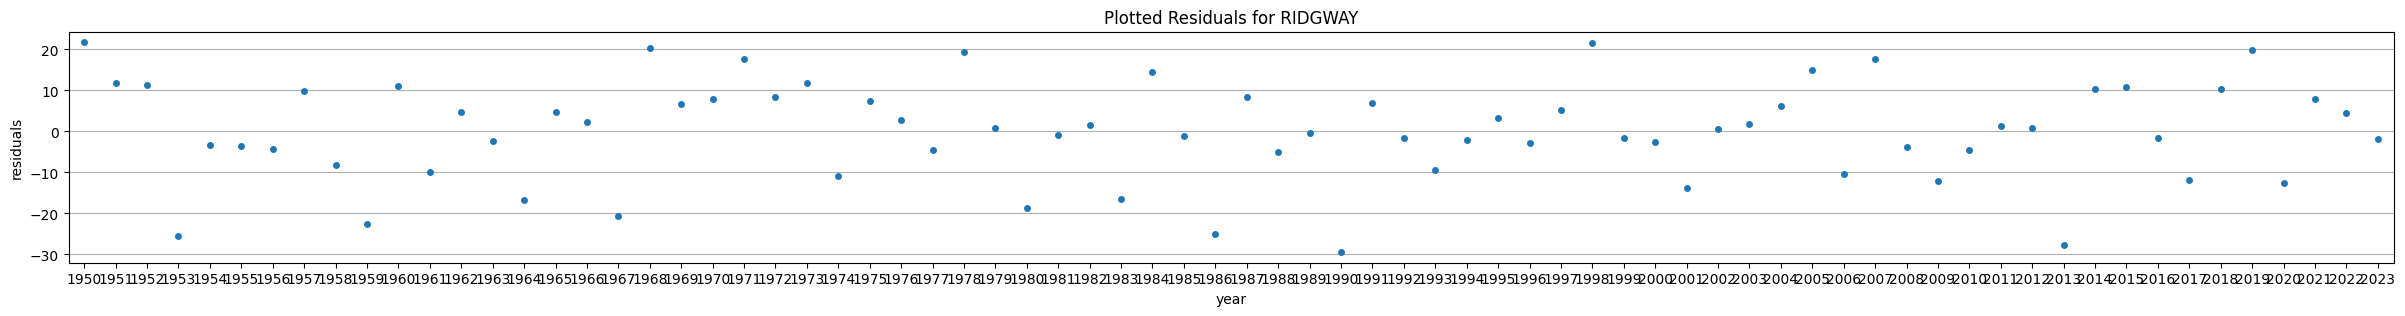

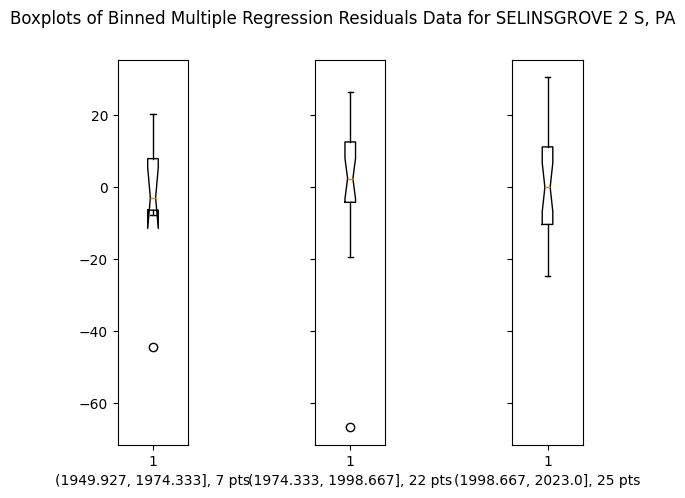

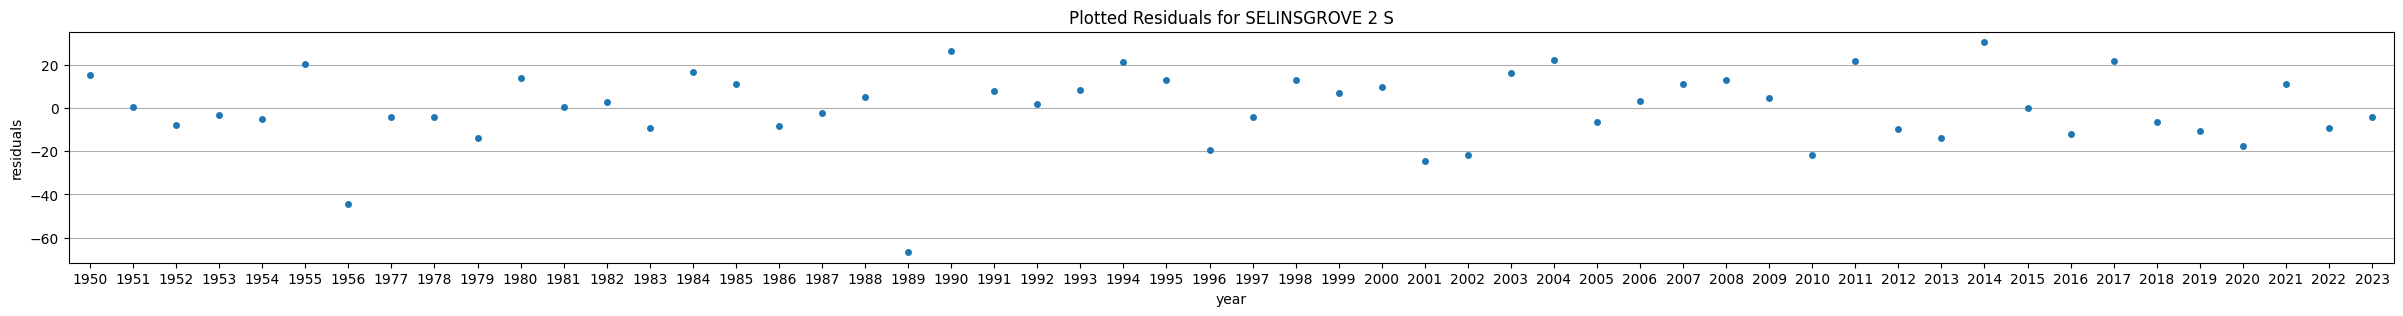

In [12]:
for station in top_stations:
    station_residuals_plotting(station, 3)

#### Residuals Plotted by Subset 

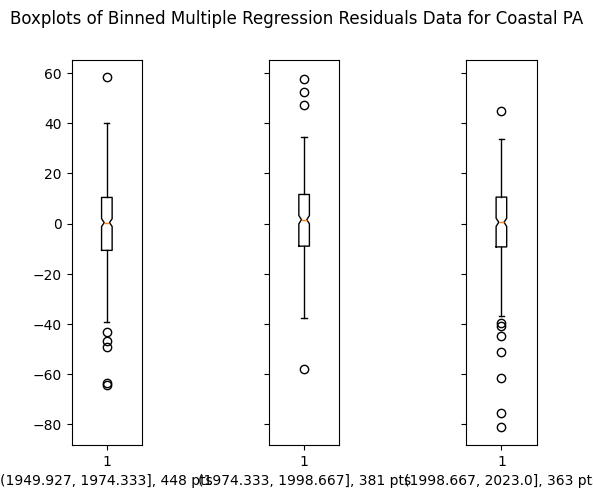

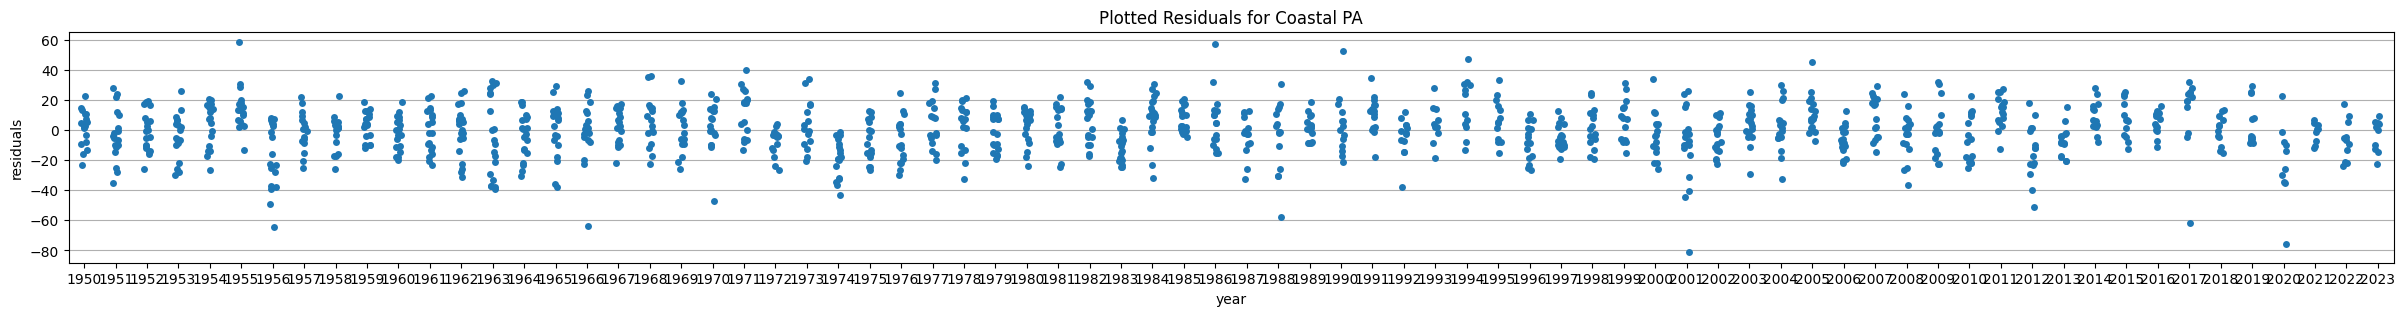

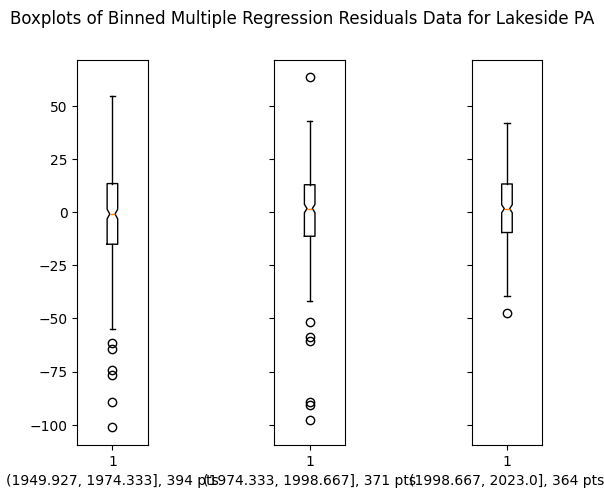

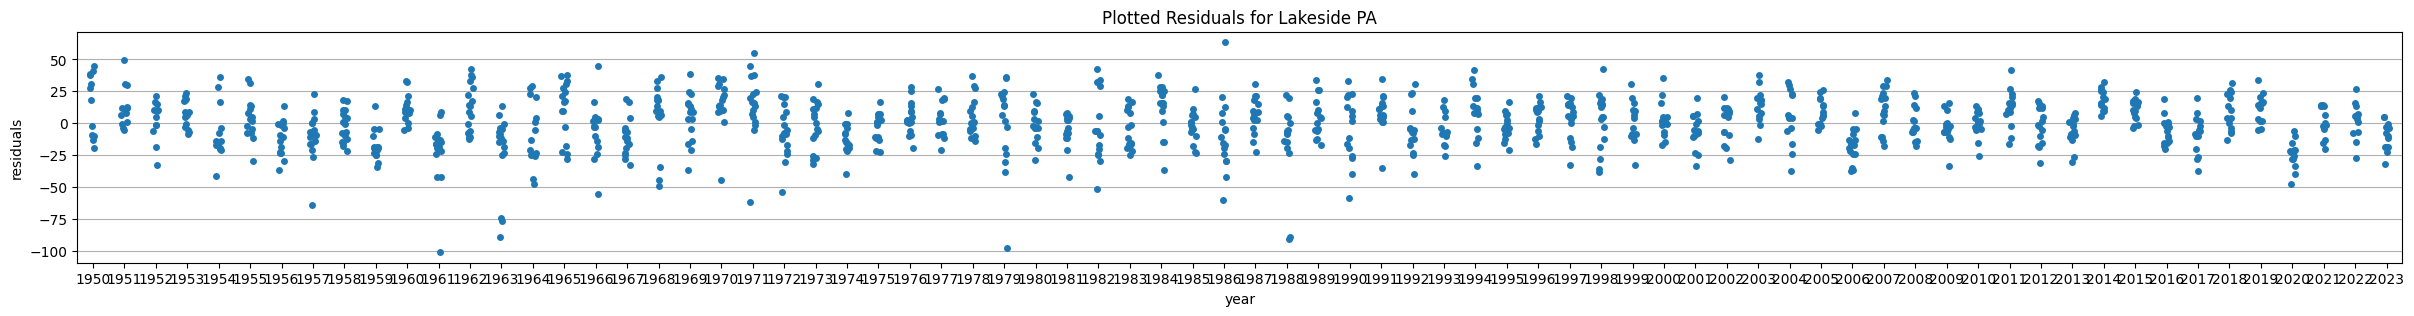

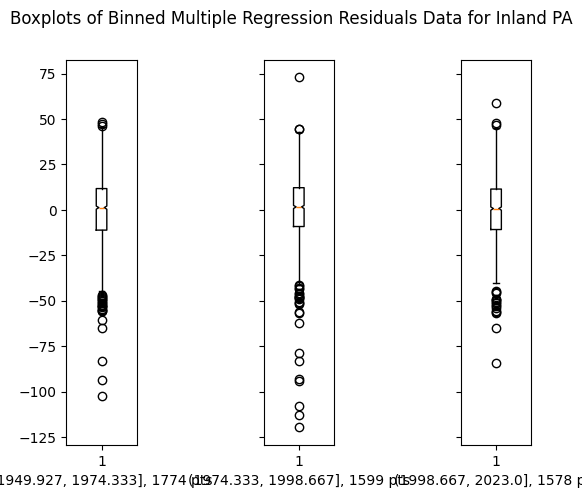

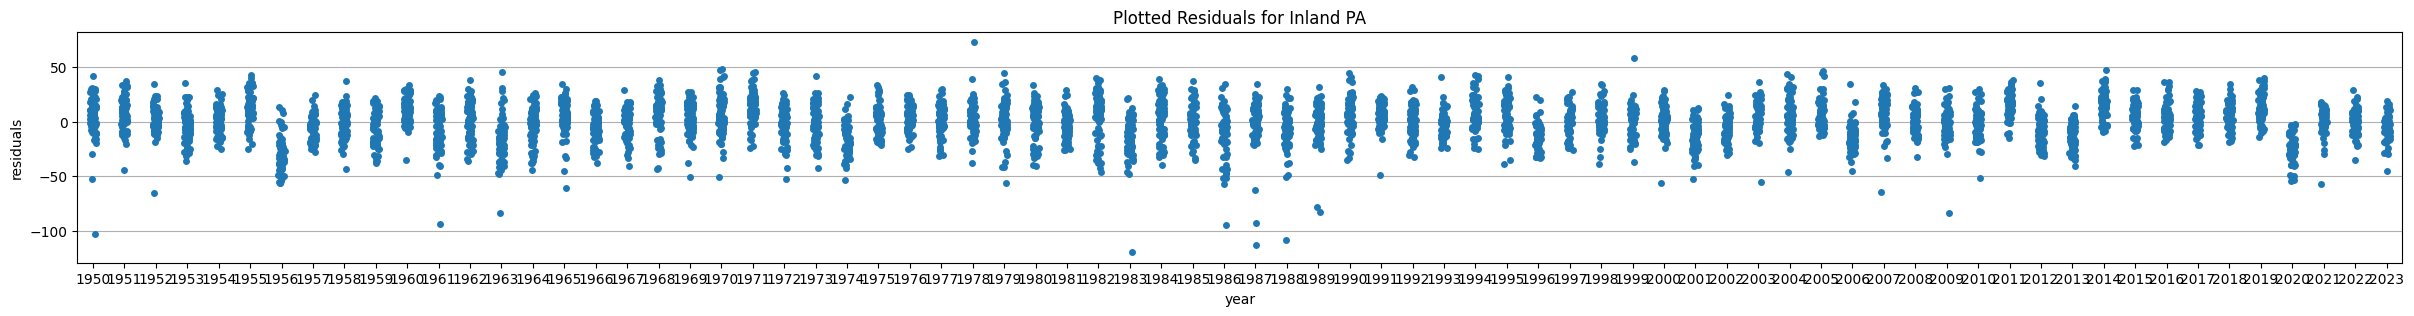

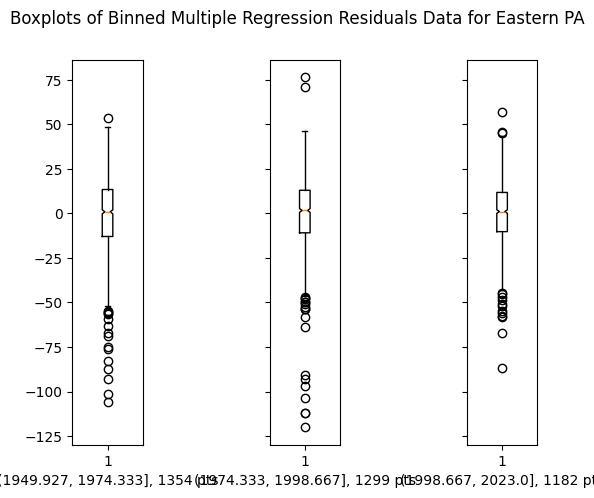

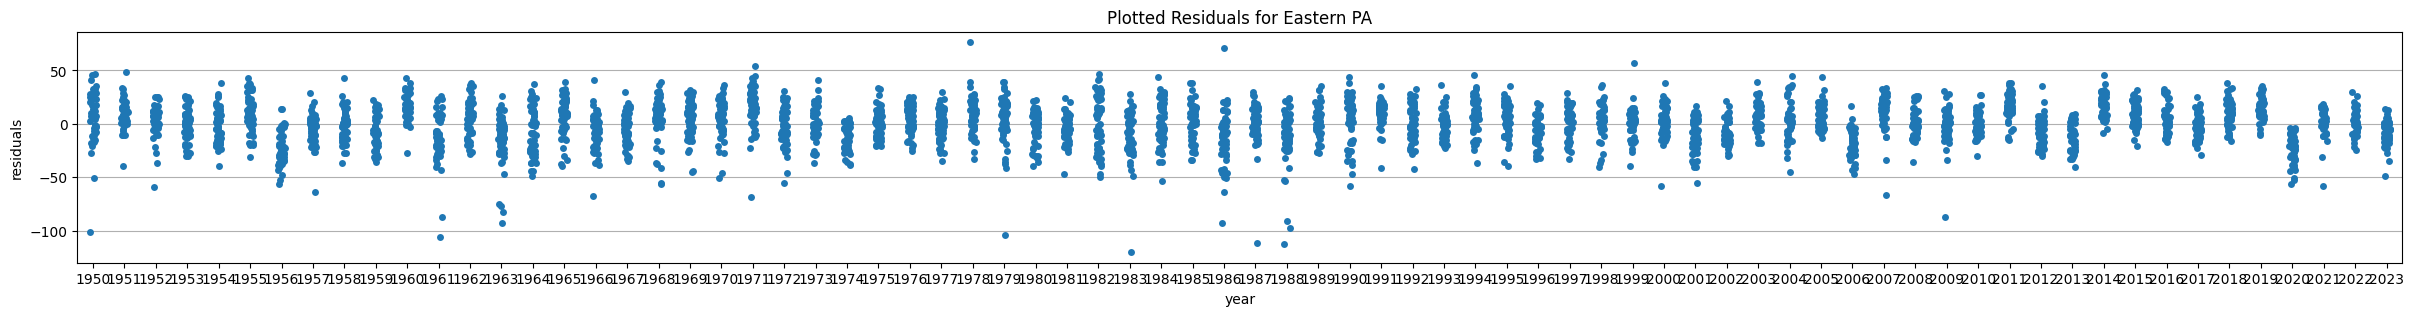

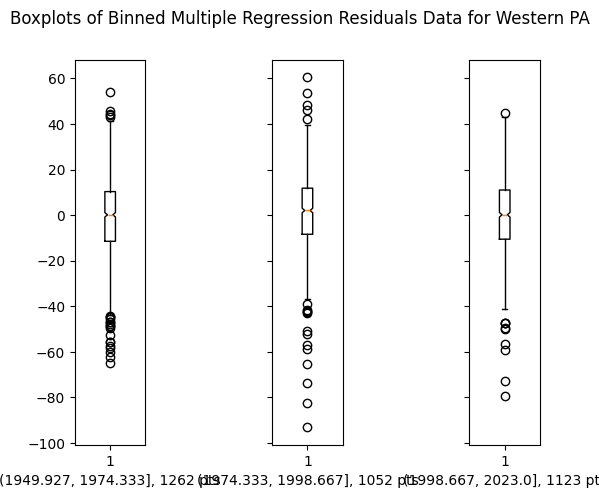

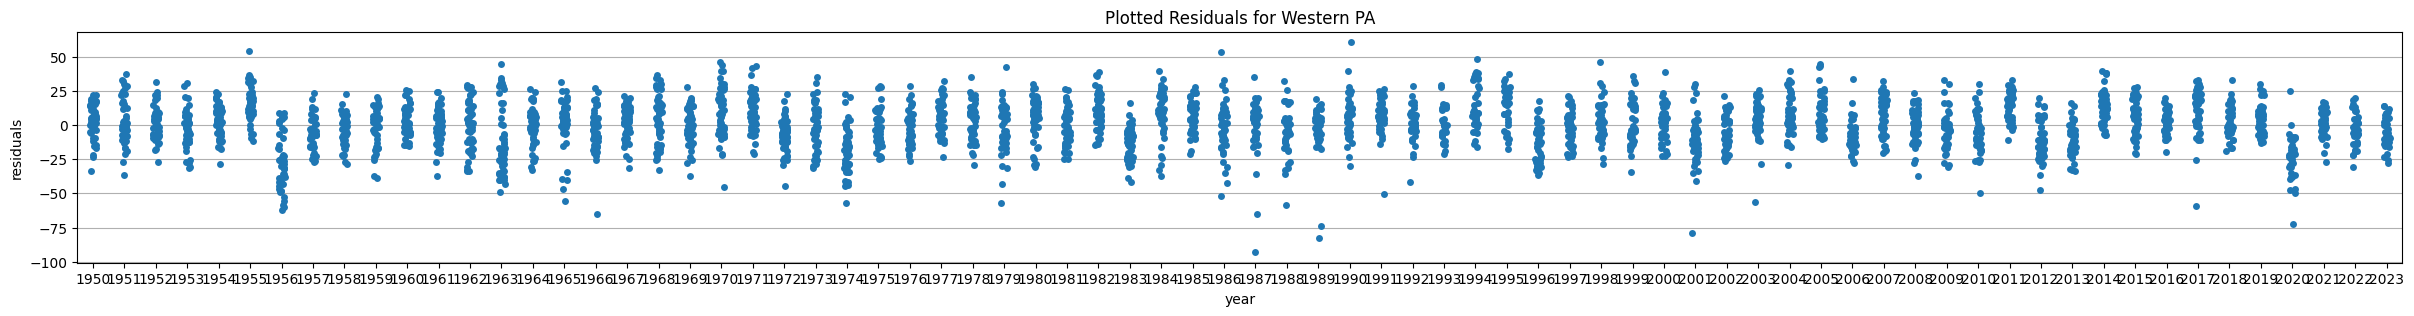

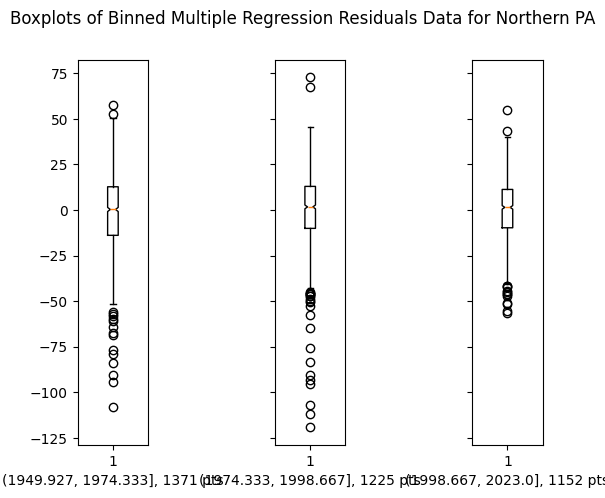

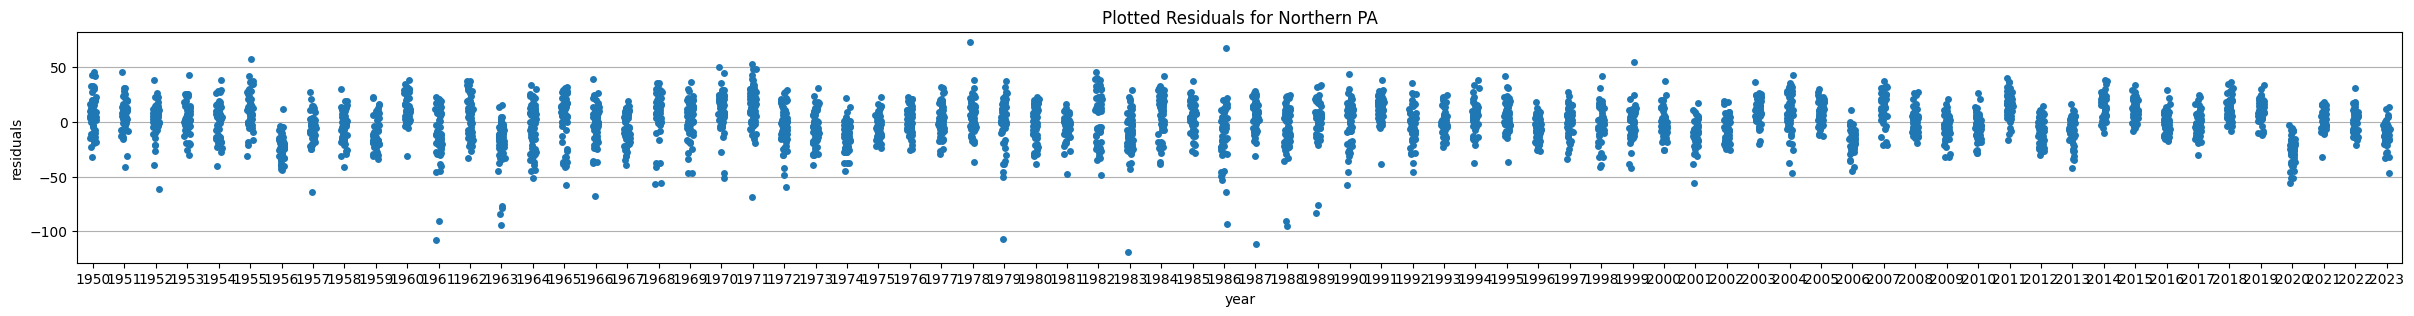

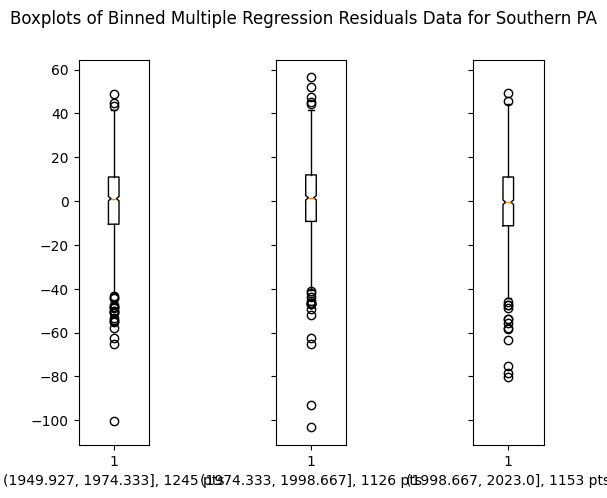

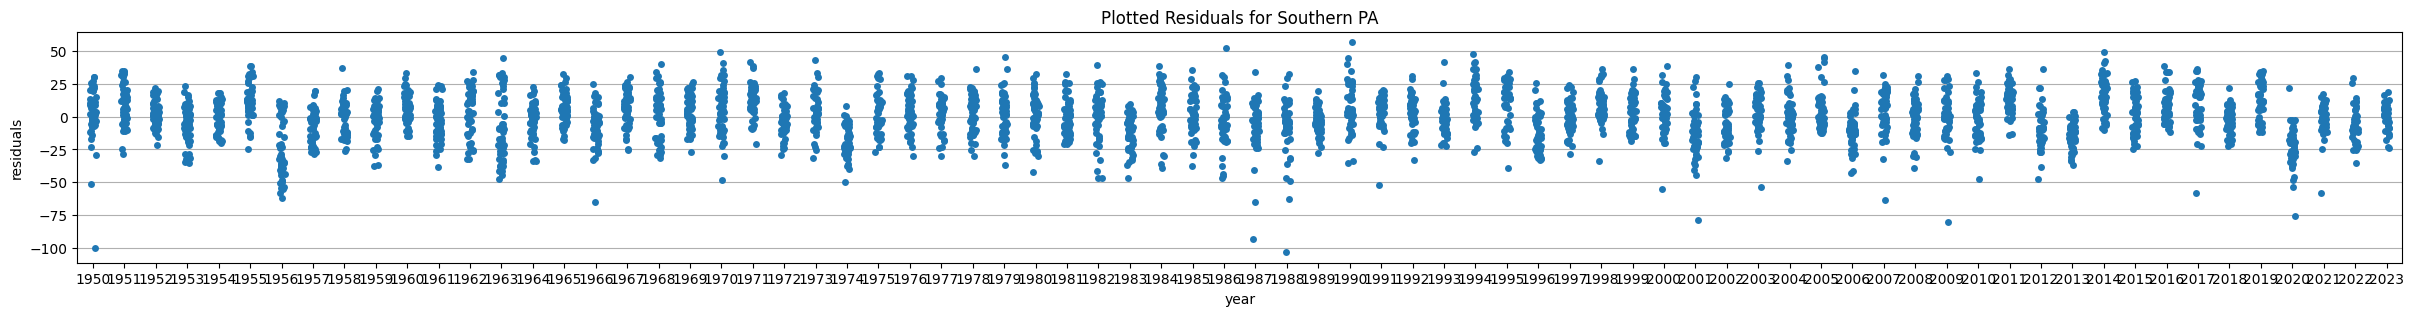

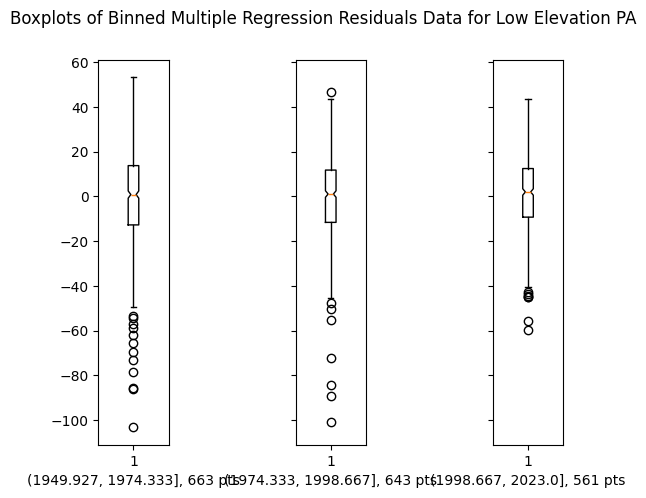

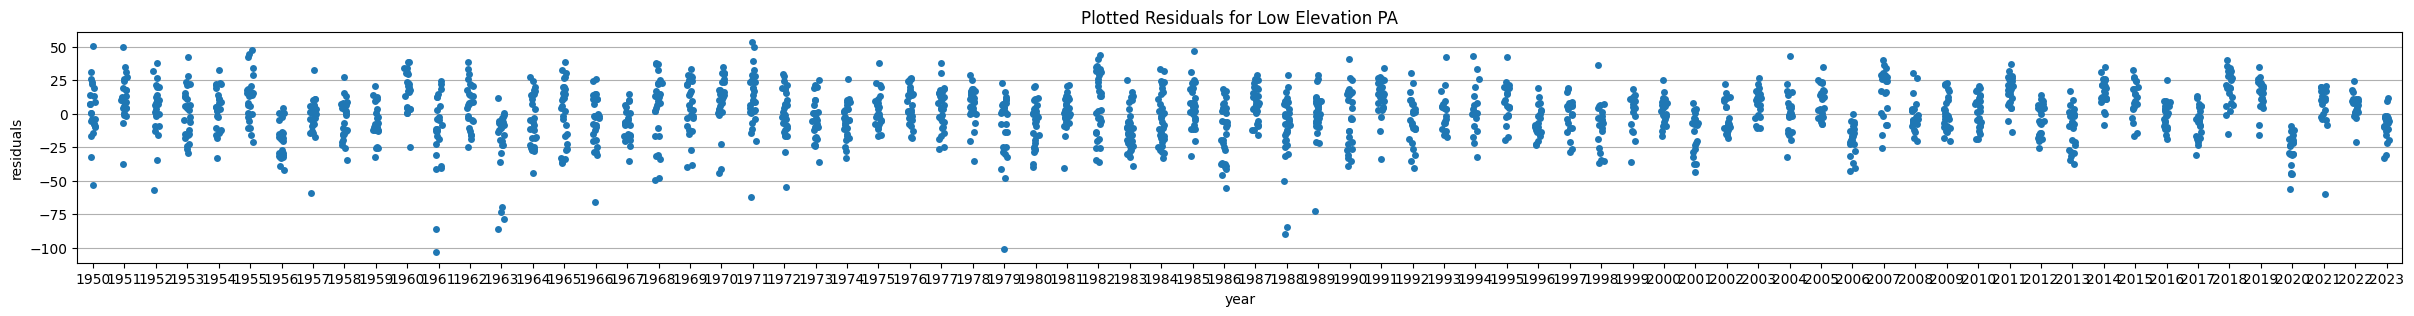

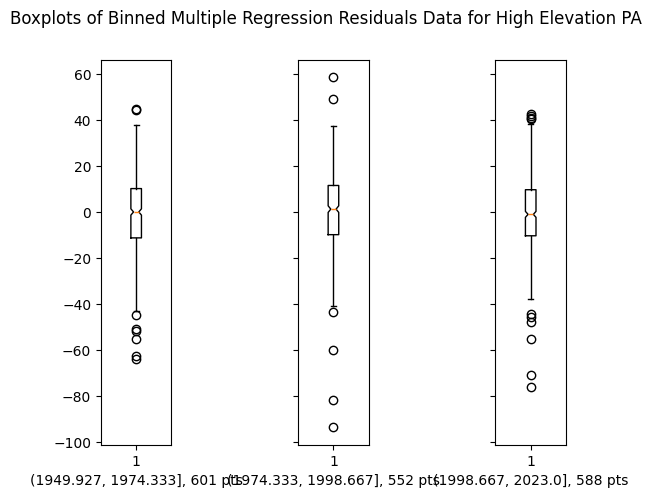

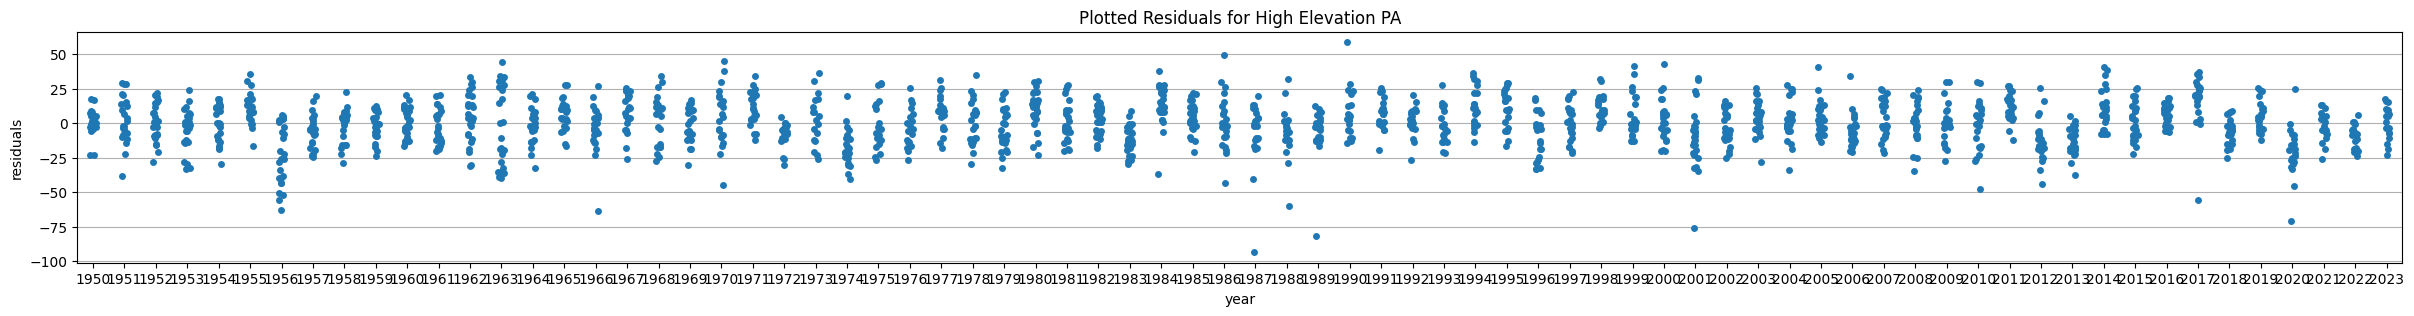

In [13]:
for subset_name, subset in subsets.items():
    subset_residuals_plotting(subset, subset_name, 3)

## Results and figures

* Bayesian modeling indicates: (all variability results significant)
    * decrease in GSL, LSF, FFF variability over time
    * decrease in GSL and earlier FFF but minimal change in LSF as DTR increases
    * increase in GSL, earlier LSF, and later FFF as PWAT increases
    * decrease in GSL as cloud cover increases
* Plotting of IQR trends in GSL and DTR
    * slight decrease in GSL IQR across entire state and all subsets
    * notable decrease (quadratic best fit) in DTR IQR across entire state and all but a few subsets, most quadratic best fit curves peak between 1980 and 1990
* Seasonal Temperature Preliminary Analysis
    * scatter plots indicate correlation between higher temperatures in spring, fall, april, october and longer growing seasons
    * DTR analysis, subset by temperature range
        * Large DTR in fall, october had greater calculated GSL variance than Small DTR in fall
        * magnitude of DTR had minimal effect on calculated GSL variance in spring, april
        * Small DTR stations had greater GSL variance for spring, april mean temperatures between 9.2 and 11 C

## Questions and blockers

* I suspect the logical next step would be to include seasonal temperature data in the set of covariates for a bayesian model to determine their impact. Is that correct?
* Not 100% confident my implementation of Bayesian modeling is correct, but close to confident -- would appreciate just a check over of my code to ensure I'm doing what you intended.

## Plan for next week

- [ ] Continue bayesian modeling & analysis
- [ ] Move towards drafting paper/poster?